**Project 6: Time Series AI (Energy Consumption Forecasting)**

**Goal: Build a Time Series System for Forecasting, Anomaly Detection, or Trend Analysis.**

In [1]:
# Project 6: Explainable Multi_Model Time Series forcasting System for HouseHold Energy Consumption: Comparing ARIMA, XGBoost, LSTM and Transformer Models
# Using data called household_power_consumption.txt.
# Dataset Source:  https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip


import pandas as pd

# Provided names
names = ["Adu W.", "Betelhem W.", "Nuru S.", "Rahel K.", "Tesfaluel K."]

# Sort alphabetically
names_sorted = sorted(names)

# Inputs
project_name = "Time Series AI for HouseHold Energy Consumption Forecasting"
group_name = "SMARTAI_Batch2_Group3"
date = "2026-03-10"

# Create table using explode () to store names in a table
df = pd.DataFrame({
    "Name": names_sorted
})

df["Project Name"] = project_name
df["Group Name"] = group_name
df["Date"] = date

# Add RowNumber starting at 1
df = df.reset_index().rename(columns={"index": "RowNumber"})
df["RowNumber"] = df["RowNumber"] + 1
print(df)


   RowNumber          Name                                       Project Name  \
0          1        Adu W.  Time Series AI for HouseHold Energy Consumptio...   
1          2   Betelhem W.  Time Series AI for HouseHold Energy Consumptio...   
2          3       Nuru S.  Time Series AI for HouseHold Energy Consumptio...   
3          4      Rahel K.  Time Series AI for HouseHold Energy Consumptio...   
4          5  Tesfaluel K.  Time Series AI for HouseHold Energy Consumptio...   

              Group Name        Date  
0  SMARTAI_Batch2_Group3  2026-03-10  
1  SMARTAI_Batch2_Group3  2026-03-10  
2  SMARTAI_Batch2_Group3  2026-03-10  
3  SMARTAI_Batch2_Group3  2026-03-10  
4  SMARTAI_Batch2_Group3  2026-03-10  


In [2]:
# Data Engineering
    # Cleaning
    # Resampling
    # Feature Engineering
# Forecasting
    # Baseline
    # XGBoost
    # ARIMA/SARIMA
    # LSTM
    # Transformer
    # Walk-forward forecasting
    # Multi-step Forecasting
# Explainability
    # Transformer Attention Visualization
# Monitoring
    # Anomaly Detection
# Trend Analysis
    # Seasonal Decomposition
    # Heatmaps
    # CalendarMap

**1. Download and Unzip file**

In [3]:
# Step 1: Direct Download in Colab

!wget https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip

--2026-03-15 22:53:06--  https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘individual+household+electric+power+consumption.zip’

individual+househol     [    <=>             ]  19.68M  26.3MB/s    in 0.7s    

2026-03-15 22:53:08 (26.3 MB/s) - ‘individual+household+electric+power+consumption.zip’ saved [20640916]



In [4]:
# Step 2: Unzip the File

!unzip individual+household+electric+power+consumption.zip


Archive:  individual+household+electric+power+consumption.zip
  inflating: household_power_consumption.txt  


In [8]:
# Data Source: https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip
# Dataset: household_power_consumption.txt
# Available Fields: Date, Time, Global_active_power, Global_reactive_power, Voltage, Global_intensity, Sub_metering_1, Sub_metering_2, Sub_metering_3
#                 : These columns come from a smart electricity meter installed in a household, measuring different aspects of electricity usage.

# Understanding the Data

# 1. Date:dd/mm/yyyy (Minimum= 2006-12-16, Maximum=2010-11-26)
# 2. Time: 1,2,3,4,....................22,23,0
# 3. Global_active_power: Total household power consumption
#                       : useful energy doing work
#                       : This is the real power actually used by appliances (measured in kilowatts (kW))
#                       : This will be the main variable used for forecasting energy demand.
#                       : Power=current * Voltage * Power factor
#                       : Power factor = Real Power / Apparent Power
#                       : Example: if Microwave = 1.2 kW, Fridge = 0.15 kW, and Lights = 0.05 kW, then Global_reactive_power= 1.4kw
# 4. Reactive power: This is electricity that oscillates between the grid and appliances but does not perform useful work.
#                  : Apparent Power (total electrical power supplied) - Real / Active Power
#                  : It happens mainly with inductive devices like refrigerators, air conditioners, washing machines, fans
#                  : These devices create magnetic fields. Energy is temporarily stored in those magnetic fields and then return it to the grid.
#                  : So the electricity flows but no net work is done.
#                  : This affects power factor. when power factor is 1, it is called perfect efficiency
# 5. Voltage : Voltage is the electrical pressure pushing current through wires
#            : Typical household voltage in Europe: 220–240 V and US: 110–120 V
# 6. Global_intensity (Current): This is the amount of electrical current flowing in the circuit.
#                              : Higher current means more electricity being consumed

# 7. Sub_metering_1 (Kitchen energy): Energy used by kitchen appliances such as microwave, coffee machine, toaster, dishwasher
# 8. Sub_metering_2 (Laundry energy): Energy used by washing machine, dryer, laundry room outlets
# 9. Sub_metering_3	(Water heater / Air Conditioning):Energy used by water heater air conditioning

# Global_active_power ≈ Kitchen + Laundry + Water heater + other appliances

**2. Build one Master dataframe, then create model-specific views from it**

In [5]:
# Build one master dataframe, then create model-specific views from it

import pandas as pd
import numpy as np

# =========================================================
# Step-1: Load the Dataset to Panda
# =========================================================

df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

# Check the available fields
# (['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2','Sub_metering_3'])
print(df.columns)

# Check Number of Rows and Columns---(2075259, 9)
print(df.shape)

# Get Minimum and Maximum Date..( 2006-12-16 17:24:00, 2010-11-26 21:02:00)
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
print(df["datetime"].min())
print(df["datetime"].max())

# Get top 5 records
df.head()

# =========================================================
# Step-2: Combine Date and Time to create Index (Timestamp)
# =========================================================

# Now the data is indexed by timestamp, which is required for time-series models
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df = df.drop(columns=["Date", "Time"])
df = df.set_index("datetime")

# Check data Size
print(df.shape)   # (2075259, 7)
print(df.index.min()) # 2006-12-16 17:24:00
print(df.index.max()) # 2010-11-26 21:02:00

# =========================================================
# Step-3: Convert data type to numeric
# =========================================================

df = df.apply(pd.to_numeric)
# Check data Type
df.dtypes

# =========================================================
# Step-4: Handle Missing Values
# =========================================================

# Check Missing Value--25,979 in each field
df.isna().sum()

# Filling Missing Data: Forward_fill/Use previous data
df = df.ffill()
# Use Forward-fill: works well for time-series
# Forward fill replaces a missing value (NaN) with the most recent previous value
# Time-series data is sequential. The previous value is usually the best estimate for the next moment if data is missing briefly
# Check missing values again:

# Check Missing Value
df.isna().sum()

# =========================================================
# Step 5 — Resample to Hourly Data
# =========================================================
# The dataset records electricity usage every minute So each hour has 60 rows.
# Resampling groups those minutes into one hourly value
# Compute average value inside each hour. So each hour becomes one aggregated observation
# Number of rows decrease from 2,075,259 to 34,589
# Energy consumption patterns are usually studied at hourly resolution
# Resampling helps with noise reduction, faster model training, clearer patterns, easier visualization. Most energy forecasting studies use hourly demand data.
# What Happens to Other Columns? mean value
# Other Resampling Options: Daily, Weekly, Monthly
# Resampling converts high-frequency time-series data into lower-frequency summaries.
df_hourly = df.resample("h").mean()

# Check data Size.....(34589, 7)
print(df_hourly.shape)

# =========================================================
# Step 6 — Time features: Linear and Cyclical Encoding
# =========================================================

df_hourly["hour"] = df_hourly.index.hour
df_hourly["day_of_week"] = df_hourly.index.dayofweek
# 0................... Monday
# 1....................Tuesday
# 5................... Saturday
# 6................... Sunday
df_hourly["month"] = df_hourly.index.month
df_hourly["weekend"] = (df_hourly.index.dayofweek >= 5).astype(int)
# 0 → weekday
# 1 → weekend

# Check the weekend regime
# A regime is a state of the system where the behavior of the data changes.
# Weekend is not cyclical like hours or months.Instead it's a binary regime indicator
df_hourly["weekend"].value_counts()  # weekday------71 %
df_hourly["weekend"].value_counts(normalize=True) * 100 # weekend---..29 %

# Cyclical encoding
# daily cycles, weekly cycles, seasonal patterns
# Time features like hour, day_of_week, month are cyclical, not linear.
# Example : hour = 23 and hour = 0: These are adjacent hours, but numerically they look far apart. Machine learning models interpret them incorrectly.
# hour = 0,1,2,...,23..Model thinks:23 is far from 0...But in reality: 23 → 0 (next hour)
# convert time into sin / cosine waves: This maps time onto a circle.
# (sin(2πt/period), cos(2πt/period)) ...They convert time values into coordinates on a unit circle,
# which helps machine-learning models understand repeating patterns.
# They convert time values into coordinates on a unit circle, which helps machine-learning models understand repeating patterns.
# Instead of linear time:we now represent time on a circle.
# Hour	sin	cos
#   0	   0	 1
#   6	   1   0
#  12	   0	-1
#  18	  -1	 0
# This captures daily cycles perfectly.

# Encode Hour of Day: There are 24 hours.
df_hourly["hour_sin"] = np.sin(2*np.pi*df_hourly["hour"]/24)
df_hourly["hour_cos"] = np.cos(2*np.pi*df_hourly["hour"]/24)
# Encode Day of Week: There are 7 days
df_hourly["dow_sin"] = np.sin(2*np.pi*df_hourly["day_of_week"]/7)
df_hourly["dow_cos"] = np.cos(2*np.pi*df_hourly["day_of_week"]/7)
# Encode Month: There are 12 months.
df_hourly["month_sin"] = np.sin(2*np.pi*df_hourly["month"]/12)
df_hourly["month_cos"] = np.cos(2*np.pi*df_hourly["month"]/12)

# Check data Size.....(34589, 17)
print(df_hourly.shape)

# Check Missing Value
df_hourly.isna().sum()

# =========================================================
# Step 7 —  Lag features
# =========================================================

# Lag features allow models to use past values
target = "Global_active_power"
# previous hour
df_hourly["lag_1"] = df_hourly[target].shift(1)
# same hour yesterday
df_hourly["lag_24"] = df_hourly[target].shift(24)
# same hour last week
df_hourly["lag_168"] = df_hourly[target].shift(168)

# Check data Size.....(34589, 20)
print(df_hourly.shape)

# Check Missing Value
df_hourly.isna().sum()
# lag_1=1
# lag_24=24
# lag_168=168

# =========================================================
# Step 8 —  Difference features
# =========================================================
# These capture hourly and daily change
df_hourly["diff_1"] = df_hourly[target].diff(1)
df_hourly["diff_24"] = df_hourly[target].diff(24)

# Check data Size.....(34589, 22)
print(df_hourly.shape)

# Check Missing Value
df_hourly.isna().sum()
# lag_1=1
# lag_24=24
# lag_168=168
# diff_1= 1
# diff_24= 24

# =========================================================
# Step 9 — Rolling features
# =========================================================

# These help to capture recent trends.
df_hourly["rolling_mean_24"] = df_hourly[target].rolling(24).mean()
df_hourly["rolling_std_24"] = df_hourly[target].rolling(24).std()

# Check data Size.....(34589, 24)
print(df_hourly.shape)

# Check Missing Value
df_hourly.isna().sum()
# lag_1=1
# lag_24=24
# lag_168=168
# diff_1= 1
# diff_24= 24
# rolling_mean_24=	23
# rolling_std_24=	23

# =========================================================
# Step 10 — Drop NA created by lag/diff/rolling
# =========================================================
df_hourly = df_hourly.dropna()

# Check data Size.....(34421, 24)--168 row is removed
print(df_hourly.shape)

# Check Missing Value---0
df_hourly.isna().sum()

# Check if the minimum index is changed
print(df_hourly.index.min()) # 2006-12-23 17:00:00
print(df_hourly.index.max()) # 2010-11-26 21:00:00

# =========================================================
# Step 11 — Final Dataset
# =========================================================
df_hourly.head()
df_hourly.shape


Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')
(2075259, 9)


/tmp/ipykernel_25531/1229114092.py:25: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


2006-12-16 17:24:00
2010-11-26 21:02:00


/tmp/ipykernel_25531/1229114092.py:37: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


(2075259, 7)
2006-12-16 17:24:00
2010-11-26 21:02:00
(34589, 7)
(34589, 17)
(34589, 20)
(34589, 22)
(34589, 24)
(34421, 24)
2006-12-23 17:00:00
2010-11-26 21:00:00


(34421, 24)

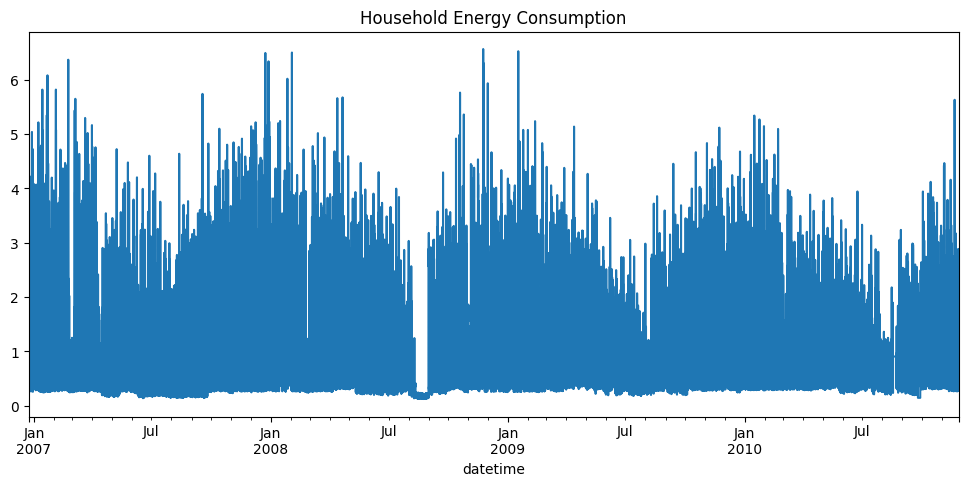

In [5]:
# =========================================================
# Step 12A — visualization of Household energy Consumption
# =========================================================

import matplotlib.pyplot as plt

df_hourly["Global_active_power"].plot(figsize=(12,5))
plt.title("Household Energy Consumption")
plt.show()


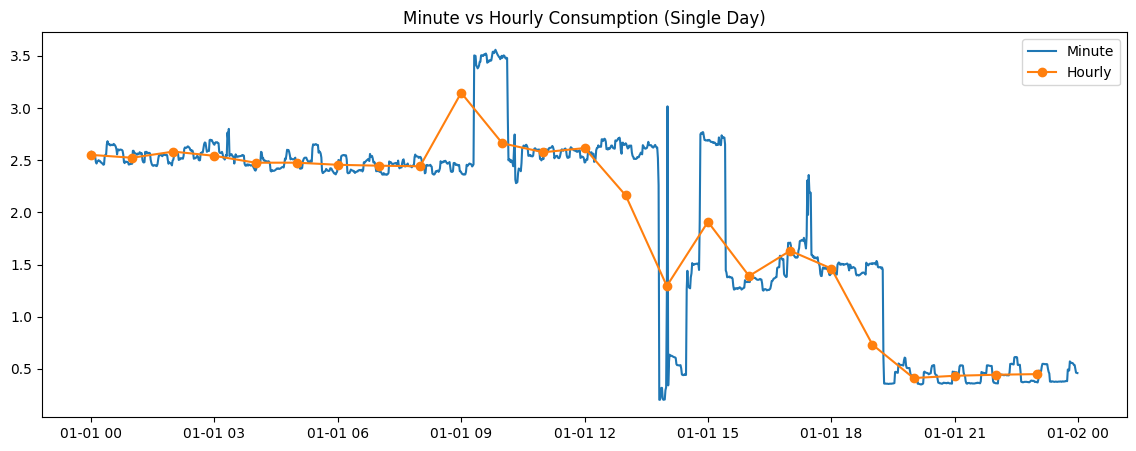

In [6]:
# =========================================================
# Step 12B — visualization of minute vs hourly consumption
# =========================================================

# Minute Data	Vs Hourly Data
# noisy	 vs smooth
# too many points vs manageable points
# hard to model	Vs easier to model

plt.figure(figsize=(14,5))
day = "2007-01-01"

plt.plot(
    df.loc[day]["Global_active_power"],
    label="Minute"
)

plt.plot(
    df_hourly.loc[day]["Global_active_power"],
    label="Hourly",
    marker="o"
)

plt.legend()
plt.title("Minute vs Hourly Consumption (Single Day)")
plt.show()


**3. Create Model Specific Views**





In [5]:
# =========================================================
# A. ARIMA / SARIMA View
# =========================================================

# ARIMA/SARIMA should use only the target series.
y_arima = df_hourly["Global_active_power"]

# =========================================================
# B. XGBoost View
# =========================================================

# XGBoost should use engineered tabular features.
xgb_features = [
    "lag_1", "lag_24", "lag_168",
    "diff_1", "diff_24",
    "rolling_mean_24", "rolling_std_24",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "weekend"
]
X_xgb = df_hourly[xgb_features]
y_xgb = df_hourly["Global_active_power"]

# =========================================================
# C. LSTM / Transformer View
# =========================================================

# For deep sequence models, avoid redundant lag features.
# Use raw signals, cyclical features, regime indicators

seq_features = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "weekend"
]

X_seq = df_hourly[seq_features]
y_seq = df_hourly["Global_active_power"]

**4. Data Split**

In [9]:
# One Common Train / Val / Test Split

# Use one time split for all models
train = df_hourly[:'2009']
val   = df_hourly['2010-01':'2010-06']
test  = df_hourly['2010-07':]

print(train.index.min()) #
print(train.index.max()) #
print(val.index.min()) #
print(val.index.max()) #
print(test.index.min()) #
print(test.index.max()) #


print(train.shape)#..........(26503, 24)
print (val.shape)#...........(4344, 24)
print(test.shape)#...........(3574, 24)

print(train.index.min()) # 2006-12-23 17:00:00
print(train.index.max()) # 2009-12-31 23:00:00

print(val.index.min()) # 2010-01-01 00:00:00
print(val.index.max()) # 2010-06-30 23:00:00

print(test.index.min()) # 2010-07-01 00:00:00
print(test.index.max()) # 2010-11-26 21:00:00

# ARIMA split...There is no Feature, only Target
y_train_arima = train["Global_active_power"]
y_val_arima   = val["Global_active_power"]
y_test_arima  = test["Global_active_power"]

# XGBoost split
X_train_xgb = train[xgb_features]
X_val_xgb   = val[xgb_features]
X_test_xgb  = test[xgb_features]

y_train_xgb = train["Global_active_power"]
y_val_xgb   = val["Global_active_power"]
y_test_xgb  = test["Global_active_power"]

# Sequence model split (only for LSTM and Transformer)

X_train_seq_df = train[seq_features]
X_val_seq_df   = val[seq_features]
X_test_seq_df  = test[seq_features]

y_train_seq_df = train["Global_active_power"]
y_val_seq_df   = val["Global_active_power"]
y_test_seq_df  = test["Global_active_power"]

2006-12-23 17:00:00
2009-12-31 23:00:00
2010-01-01 00:00:00
2010-06-30 23:00:00
2010-07-01 00:00:00
2010-11-26 21:00:00


**5. Scaling**

In [9]:
# Scaling only for XGBoost, LSTM, and Transformer
# Scaling (normalizing) features is used to make numeric variables lie in a similar range, which helps many machine-learning algorithms learn more efficiently

# XGBoost

from sklearn.preprocessing import StandardScaler

scaler_xgb = StandardScaler()
X_train_xgb_scaled = scaler_xgb.fit_transform(X_train_xgb)
X_val_xgb_scaled   = scaler_xgb.transform(X_val_xgb)
X_test_xgb_scaled  = scaler_xgb.transform(X_test_xgb)

# LSTM / Transformer
# LSTM is a neural network that uses gradient-based optimization (backpropagation). Neural networks are very sensitive to feature magnitude.
# If features have very different scales, the model may focus disproportionately on large-scale features.

scaler_seq = StandardScaler()
X_train_seq_scaled = scaler_seq.fit_transform(X_train_seq_df)
X_val_seq_scaled   = scaler_seq.transform(X_val_seq_df)
X_test_seq_scaled  = scaler_seq.transform(X_test_seq_df)

**6. Sequence Builder**

In [10]:
# Sequence Builder (Reusable for LSTM & Transformer)
# The sequence builder creates sliding windows of past observations
# We need a sequence builder for LSTM/Transformer because LSTMs are designed to learn from ordered sequences of past observations, not from independent rows
# They expect input in the form (samples, time_steps, features), while most datasets are stored as (samples, features).
# X shape (26479, 24, 14)


import numpy as np

LOOKBACK = 24

def create_sequences(X, y, lookback):
    X = np.asarray(X)
    y = np.asarray(y)

    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])

    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_seq_scaled, y_train_seq_df.values, LOOKBACK)
X_val_seq, y_val_seq     = create_sequences(X_val_seq_scaled, y_val_seq_df.values, LOOKBACK)
X_test_seq, y_test_seq   = create_sequences(X_test_seq_scaled, y_test_seq_df.values, LOOKBACK)

In [11]:
# =========================================================
# 8. SUMMARY OF WHAT TO USE FOR EACH MODEL
# =========================================================

print("\nARIMA input:")
print("y_train_arima shape:", y_train_arima.shape)

print("\nXGBoost input:")
print("X_train_xgb_scaled:", X_train_xgb_scaled.shape)
print("y_train_xgb:", y_train_xgb.shape)

print("\nLSTM / Transformer input:") #............24 less compared to others because lockback=24
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)


ARIMA input:
y_train_arima shape: (26503,)

XGBoost input:
X_train_xgb_scaled: (26503, 14)
y_train_xgb: (26503,)

LSTM / Transformer input:
X_train_seq: (26479, 24, 14)
y_train_seq: (26479,)


**7. A single end-to-end modeling block for all four models: Baseline, XGBoost, Arima/Sarima, LSTM, Transformer**

In [12]:
# 1) Imports + helper metric function

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf

# MAE = Mean Absolute Error: measures the average absolute difference between the predicted value and the real value. treats all errors equally.
# RMSE= Root Mean Squared Error: measures error but penalizes large errors more strongly. Because errors are squared, large mistakes count much more

def evaluate_regression(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} MAE : {mae}")
    print(f"{model_name} RMSE: {rmse}")
    return mae, rmse

In [13]:
# 2) Baseline Persistence Model

# The persistence model assumes the next value will be the same as the most recent value. Because the latest observed value is the best guess
# Without a baseline, you cannot tell if your model is good

# Prediction = previous observation
# Baseline models provide a minimum benchmark

baseline_pred = y_test_xgb.shift(1).dropna()
baseline_true = y_test_xgb.loc[baseline_pred.index]

baseline_mae, baseline_rmse = evaluate_regression(
    baseline_true,
    baseline_pred,
    model_name="Baseline"
)

# The persistence baseline assumes the next electricity demand equals the most recent observation.
# This simple benchmark establishes a minimum performance threshold that more advanced forecasting models must outperform

Baseline MAE : 0.3581535870883478
Baseline RMSE: 0.562038420463182


XGBoost MAE : 0.017137649527447278
XGBoost RMSE: 0.029319586243191146


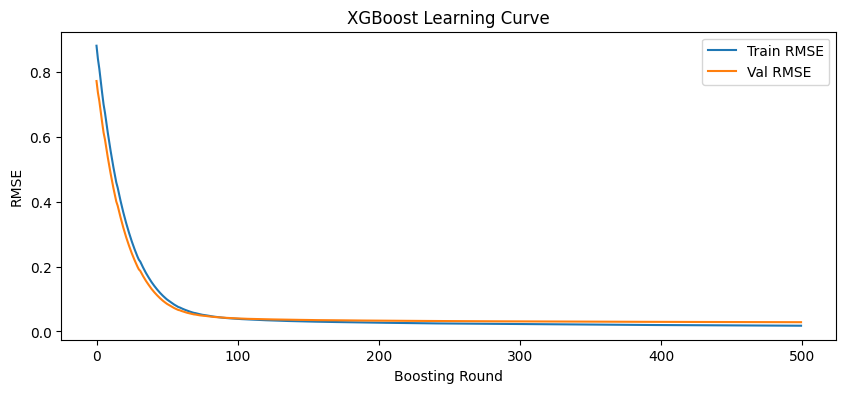

In [14]:
# 3) XGBoost Model: Machine Learning Model

# XGBoost uses engineered tabular features and it is strong tabular baseline
# Handles nonlinear patterns, Works well with engineered features(lags, rolling mean, diff), Fast training, Strong performance


xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse"
)

xgb.fit(
    X_train_xgb_scaled,
    y_train_xgb,
    eval_set=[(X_train_xgb_scaled, y_train_xgb), (X_val_xgb_scaled, y_val_xgb)],
    verbose=False
)

# predictions

y_pred_xgb = xgb.predict(X_test_xgb_scaled)

# evaluation
xgb_mae, xgb_rmse = evaluate_regression(
    y_test_xgb,
    y_pred_xgb,
    model_name="XGBoost"
)

# learning curves

evals = xgb.evals_result()

plt.figure(figsize=(10,4))
plt.plot(evals["validation_0"]["rmse"], label="Train RMSE")
plt.plot(evals["validation_1"]["rmse"], label="Val RMSE")
plt.title("XGBoost Learning Curve")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.legend()
plt.show()

# Observations:
# Early training (0–50 trees): Error drops very fast.Because the model quickly learns simple patterns:lag relationships, daily cycle, weekly cycle
# Middle stage (50–120 trees): Error still improves but more slowly. The model starts learning more subtle relationships.
# After ~120 trees: Both curves flatten.That means the model has learned almost everything it can and adding more trees does not improve much.
# Train RMSE ≈ Validation RMSE. This means No strong overfitting and Good generalization
# Model Error: XGBoost MAE  = 0.0171, XGBoost RMSE = 0.0293. These are very small errors for electricity demand forecasting.
# Compare to Baseline, XGBoost Model is actually performing very well.
# The learning curve tell us
# 1. Model learns quickly
# 2. No overfitting
# 3. Validation closely matches training
# 4. Around 100 trees is enough
# 5. Model performance is strong
# This model is well trained, stable, not overfitting, producing strong predictions

In [15]:
# 4) ARIMA /SARIMA Model: Statistical Model

# ARIMA uses only the target
# ARIMA models non-seasonal time series.ARIMA assumes the series only depends on recent past values
# ARIMA assumes the series only depends on recent past values
# ARIMA was weak because hourly electricity has strong seasonality. SARIMA is more appropriate. Because electricity demand repeats daily
# SARIMA models: daily cycles, weekly cycles, seasonal repetition
# ARIMA handles only Trend but SARIMA handles both trend and seasonality
# SARIMA only uses the target variable itself
# SARIMA only sees Global_active_power. But electricity demand depends on time of day, weekday/weekend, behavior patterns
# SARIMA Also Struggles with High-Frequency Data
# Hourly electricity usage contains irregular spikes, SARIMA assumes smooth linear structure and electricity demand is not perfectly linear.
# SARIMA cannot easily model multiple seasonalities (hourly, daily, weekly...)

sarima_model = SARIMAX(
    y_train_arima,
    order=(2,1,2),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

# forecast on test horizon

sarima_forecast = sarima_result.forecast(steps=len(y_test_arima))
sarima_forecast = pd.Series(sarima_forecast.values, index=y_test_arima.index)

sarima_mae, sarima_rmse = evaluate_regression(
    y_test_arima,
    sarima_forecast,
    model_name="SARIMA"
)

# Observation:
# SARIMA barely predicts anything useful.
# The SARIMA model performed poorly compared to machine learning models because it relies only on the historical values of the target series
# and assumes linear relationships. Electricity consumption exhibits nonlinear patterns influenced by time-of-day and behavioral factors,
# which are better captured by models such as XGBoost that incorporate engineered temporal features.

# SARIMA failed because:
# 1) no feature usage
# 2) linear assumption
# 3) single-seasonality limitation
# 4) high-frequency behavioral data

SARIMA MAE : 1.2415152496544428
SARIMA RMSE: 1.399398738993546


Epoch 1/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.4596 - rmse: 0.6780 - val_loss: 0.2870 - val_rmse: 0.5357 - learning_rate: 0.0010
Epoch 2/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3433 - rmse: 0.5859 - val_loss: 0.2782 - val_rmse: 0.5275 - learning_rate: 0.0010
Epoch 3/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3181 - rmse: 0.5640 - val_loss: 0.2645 - val_rmse: 0.5143 - learning_rate: 0.0010
Epoch 4/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3093 - rmse: 0.5562 - val_loss: 0.2667 - val_rmse: 0.5164 - learning_rate: 0.0010
Epoch 5/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3028 - rmse: 0.5502 - val_loss: 0.2571 - val_rmse: 0.5071 - learning_rate: 0.0010
Epoch 6/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.2952 - rmse: 0.5434 - val_loss: 0.2638 - val_rmse: 0.5136 - learning_rate: 0.0010
Epoch 7/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.2886 - rmse: 0.5372 - val_loss: 0.2535 - val_rmse: 0.5034 - learnin

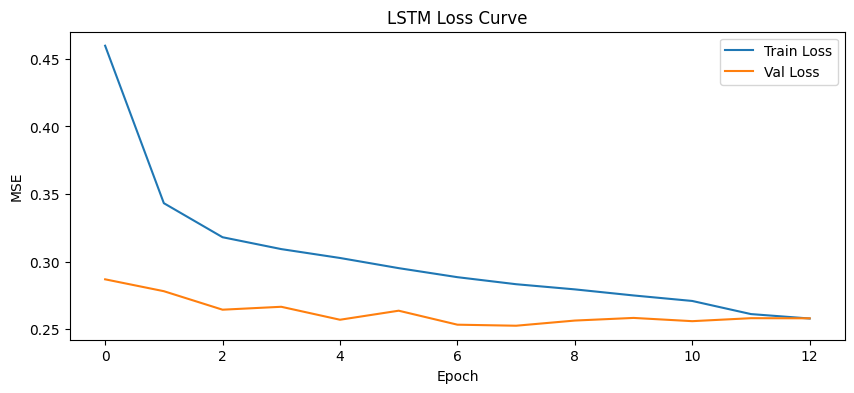

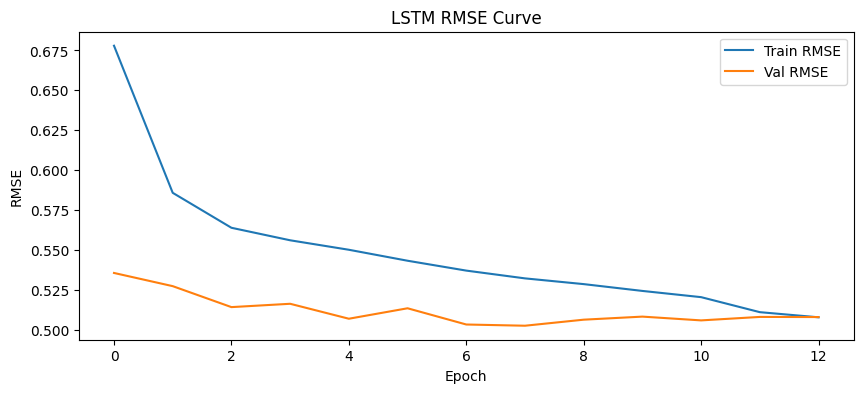

In [16]:
# 5) LSTM Model: Deep Learning Model

# LSTM uses sequence-friendly columns
# A sequence-friendly column is a feature that naturally varies over time and makes sense in sequence form
# Non-Sequence Friendly Features are features that already summarize history (e.g. lag_1, rolling_mean_24, rolling_std_24, diff_24)

tf.keras.backend.clear_session()

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_train_seq.shape[2])),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-5)
]

history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=callbacks
)

y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()

lstm_mae, lstm_rmse = evaluate_regression(
    y_test_seq,
    y_pred_lstm,
    model_name="LSTM"
)

# plots
plt.figure(figsize=(10,4))
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Val Loss")
plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history_lstm.history["rmse"], label="Train RMSE")
plt.plot(history_lstm.history["val_rmse"], label="Val RMSE")
plt.title("LSTM RMSE Curve")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.show()

# Observation on the loss curve:
# Early epochs (0–3): Loss drops quickly:
   # Train: 0.46 → 0.31
   # Val:   0.29 → 0.26
# The model quickly learns simple patterns
# Middle epochs (3–8): Training loss keeps decreasing slowly AND Validation loss oscillates slightly.
# This means Model is learning but not generalizing much better.
# Later epochs (8–16): Training loss continues dropping but Validation loss flattens.
# This means the model has learned almost everything it can.
# There is no strong overfitting because validation loss does not explode.
# LSTM MAE : 0.3155192732810974 and LSTM RMSE: 0.4548815192027725: The model generalizes reasonably well. But it does not outperform XGBoost.
# Why? small dataset size. Deep learning typically needs hundreds of thousands millions
# or sequence length (LOOKBACK = 24) but electricity demand has patterns like weekly cycle → 168 and model cannot see weekly patterns.
# XGBoost > LSTM
# LSTM → learning but limited

Epoch 1/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.8893 - rmse: 0.9362 - val_loss: 0.5891 - val_rmse: 0.7676 - learning_rate: 0.0010
Epoch 2/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.6700 - rmse: 0.8183 - val_loss: 0.4732 - val_rmse: 0.6879 - learning_rate: 0.0010
Epoch 3/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.5510 - rmse: 0.7422 - val_loss: 0.4597 - val_rmse: 0.6780 - learning_rate: 0.0010
Epoch 4/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.4945 - rmse: 0.7031 - val_loss: 0.4060 - val_rmse: 0.6372 - learning_rate: 0.0010
Epoch 5/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.4444 - rmse: 0.6666 - val_loss: 0.4245 - val_rmse: 0.6515 - learning_rate: 0.0010
Epoch 6/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.4229 - rmse: 0.6503 - val_loss: 0.3946 - val_rmse: 0.6282 - learning_rate: 0.0010
Epoch 7/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.4074 - rmse: 0.6383 - val_loss: 0.4048 - val_rmse: 0.6362 - learni

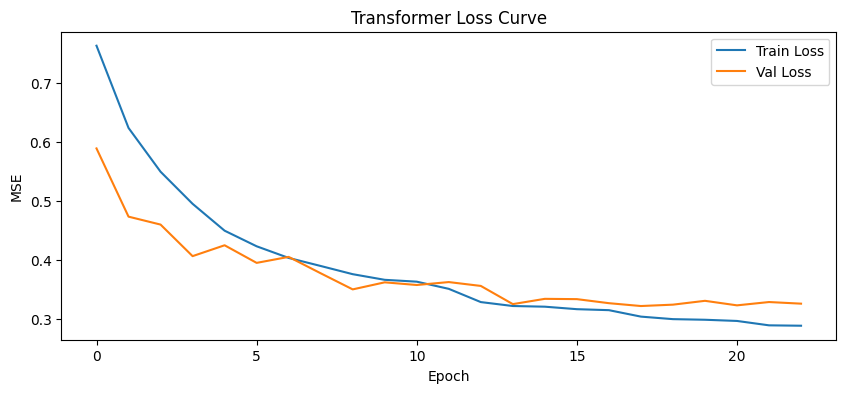

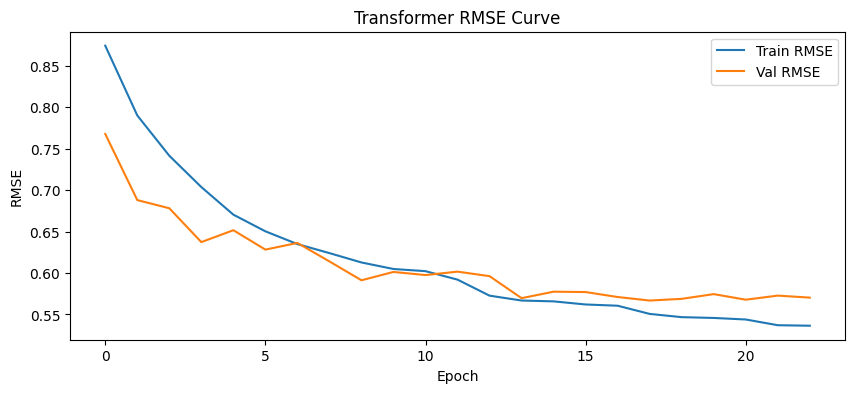

In [ ]:
# 6) Transformer: Deep Learning Model

# Transformer use sequence-friendly columns

def build_transformer(input_shape):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Dense(64)(inputs)

    attention = tf.keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=16
    )(x, x)

    x = tf.keras.layers.Add()([x, attention])
    x = tf.keras.layers.LayerNormalization()(x)

    ff = tf.keras.layers.Dense(128, activation="relu")(x)
    ff = tf.keras.layers.Dropout(0.1)(ff)
    ff = tf.keras.layers.Dense(64)(ff)

    x = tf.keras.layers.Add()([x, ff])
    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model


tf.keras.backend.clear_session()

transformer = build_transformer(
    input_shape=(LOOKBACK, X_train_seq.shape[2])
)

history_trans = transformer.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=callbacks
)

y_pred_trans = transformer.predict(X_test_seq, verbose=0).flatten()

trans_mae, trans_rmse = evaluate_regression(
    y_test_seq,
    y_pred_trans,
    model_name="Transformer"
)

# plots
plt.figure(figsize=(10,4))
plt.plot(history_trans.history["loss"], label="Train Loss")
plt.plot(history_trans.history["val_loss"], label="Val Loss")
plt.title("Transformer Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history_trans.history["rmse"], label="Train RMSE")
plt.plot(history_trans.history["val_rmse"], label="Val RMSE")
plt.title("Transformer RMSE Curve")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.show()

# Observations:
# Early Training (Epoch 0–4): Train loss drops quickly and Validation loss drops quickly. Train loss: 0.75 → 0.45 and Validation loss:0.58 → 0.41
# This means The Transformer quickly learns basic time-series structure
# Middle Training (Epoch 5–12): Train loss keeps decreasing and Validation loss oscillates slightly. Train: 0.42 → 0.33 and Val:   0.40 → 0.36
# This indicates The model is learning more subtle relationships, but improvements are smaller.
# Late Training (Epoch 12–22): Train loss continues decreasing slightly:0.33 → 0.29 and Validation loss flattens:~0.33
# This means The model has reached its learning capacity.
# Is There Overfitting? Overfitting occurs when train loss ↓ validation loss ↑.
# But here train and validation curves stay close together and validation does not increase dramatically
# This means The model is NOT overfitting. Instead it has converged.
# the Gap Between Curves is small. Train MSE ≈ 0.29 and Val MSE ≈ 0.33, it is Small gap → so good generalization, No overfitting

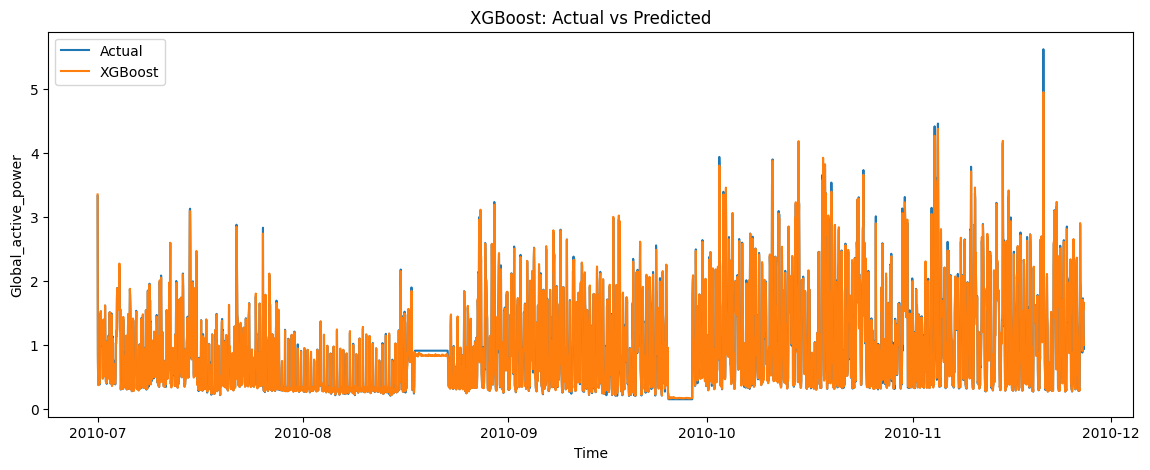

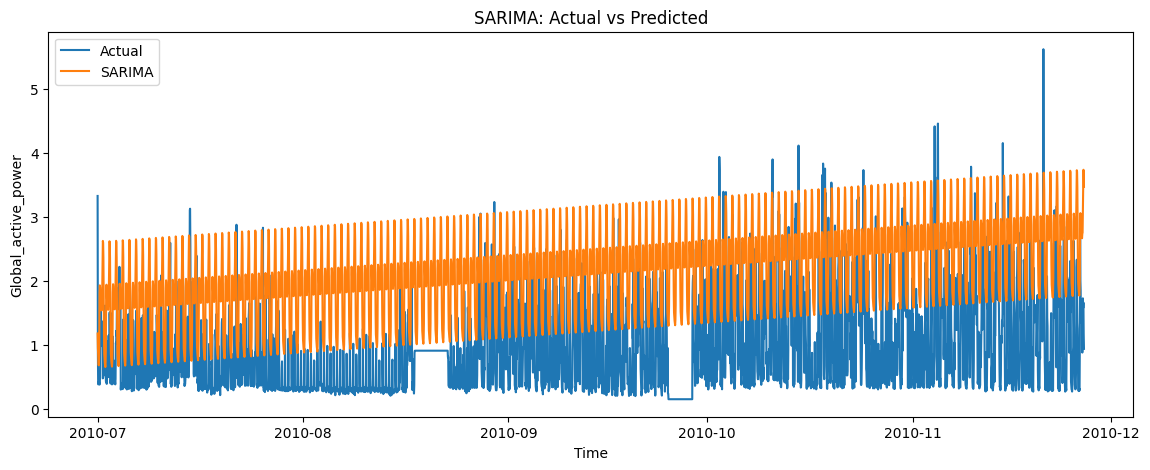

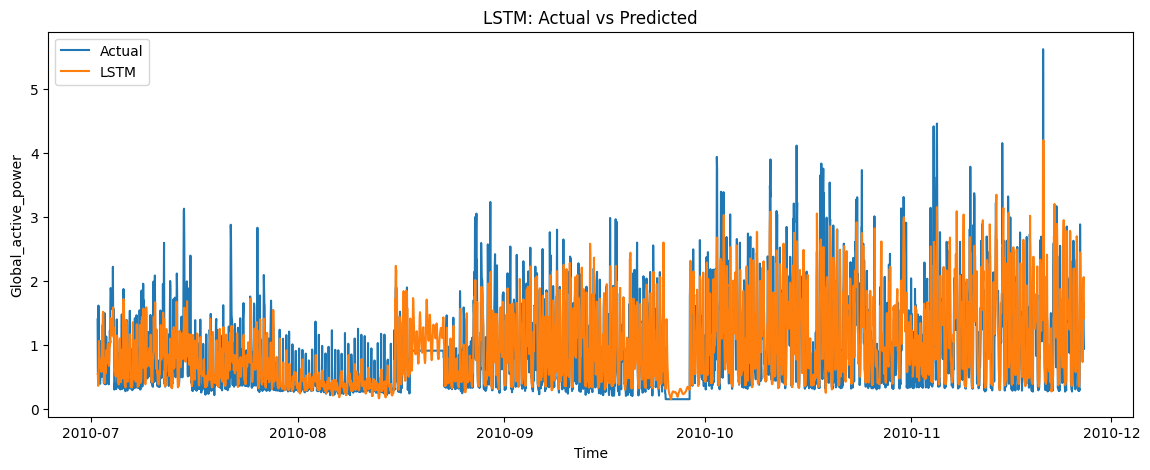

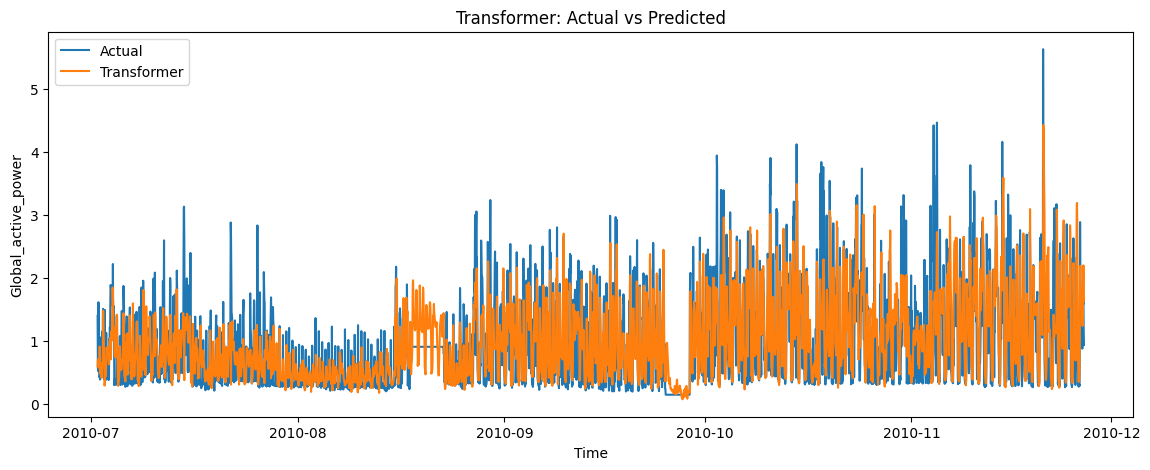

         Model       MAE      RMSE
0     Baseline  0.358154  0.562038
1      XGBoost  0.017138  0.029320
2       SARIMA  1.241515  1.399399
3         LSTM  0.315519  0.454882
4  Transformer  0.371603  0.521998


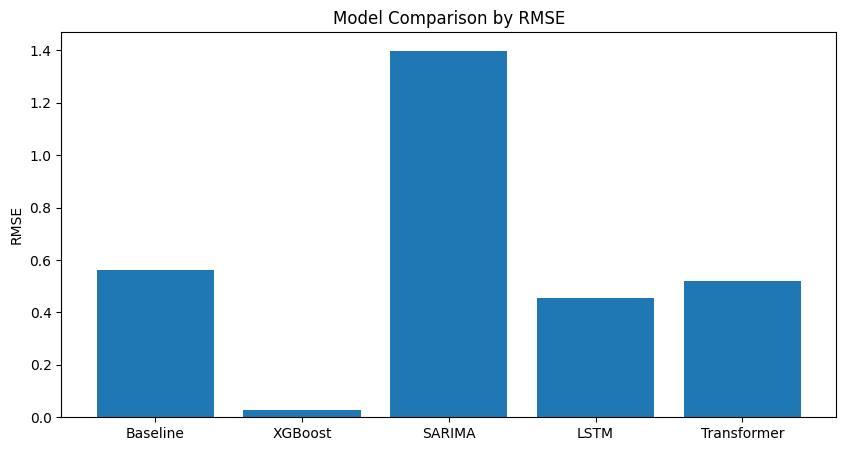

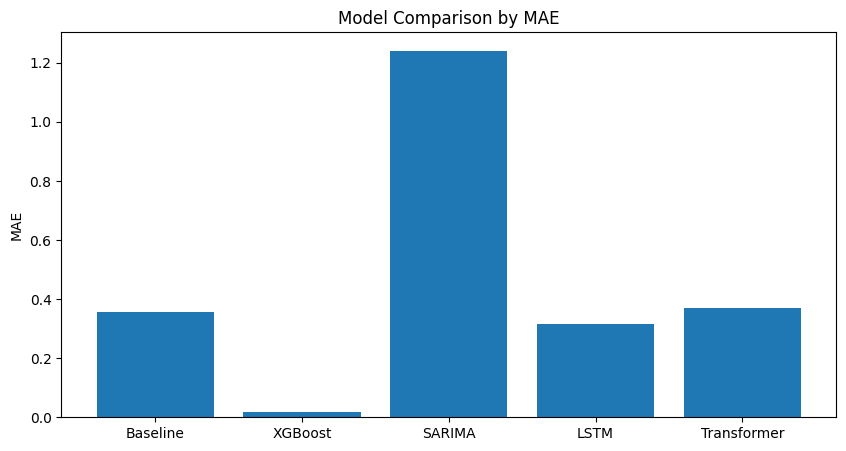

In [ ]:
# 7) Actual vs Predicted Plots

# XGBoost

plt.figure(figsize=(14,5))
plt.plot(test.index, y_test_xgb.values, label="Actual")
plt.plot(test.index, y_pred_xgb, label="XGBoost")
plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

# Observation:
# XGBoost: Actual vs Predicted: Tree models are excellent for tabular time-series with engineered features

# SARIMA
plt.figure(figsize=(14,5))
plt.plot(y_test_arima.index, y_test_arima.values, label="Actual")
plt.plot(sarima_forecast.index, sarima_forecast.values, label="SARIMA")
plt.title("SARIMA: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

# Observation:
#SARIMA: Actual vs Predicted: # Observation:
#The SARIMA plot shows a systematic failure pattern. Predictions form smooth oscillations and Actual values are highly irregular and spiky

# LSTM
test_index_seq = test.index[LOOKBACK:]

plt.figure(figsize=(14,5))
plt.plot(test_index_seq, y_test_seq, label="Actual")
plt.plot(test_index_seq, y_pred_lstm, label="LSTM")
plt.title("LSTM: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

# Observations: LSTM: Actual vs Predicted
# Your LSTM predictions follow the general shape but miss many spikes.

# Transformer
plt.figure(figsize=(14,5))
plt.plot(test_index_seq, y_test_seq, label="Actual")
plt.plot(test_index_seq, y_pred_trans, label="Transformer")
plt.title("Transformer: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

# Observations: Transformer: Actual vs Predicted
# The Transformer behaves similarly to LSTM: captures general patterns but misses sudden spikes

# Final Model Comparison Table
results = pd.DataFrame({
    "Model": ["Baseline", "XGBoost", "SARIMA", "LSTM", "Transformer"],
    "MAE": [baseline_mae, xgb_mae, sarima_mae, lstm_mae, trans_mae],
    "RMSE": [baseline_rmse, xgb_rmse, sarima_rmse, lstm_rmse, trans_rmse]
})

print(results)

# Final Model Comparison Bar Chart
plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.show()

# Observations:
# SARIMA  → extremely poor
# Baseline → moderate
# LSTM → moderate improvement
# Transformer → similar
# XGBoost → dramatically better

plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison by MAE")
plt.ylabel("MAE")
plt.show()

# Observations:
# Model Performance Summary

# Model            	MAE	        RMSE
# Baseline	       0.358	     0.562
# XGBoost	         0.017	     0.029
# SARIMA	         1.241	     1.399
# LSTM	           0.315	     0.455
# Transformer	     0.372	     0.522

# Conclusion:
# A. Best Model: XGBoost is dramatically better than all other models.
# It reduces RMSE from 0.56 → 0.03, which is roughly ~95% error reduction vs baseline
# This means the model captured the structure of the data extremely well.
# B. Second Tier: LSTM and Transformer are better than SARIMA but worse than baseline in some cases.
# This indicates deep models are learning something but they are not ideal for this dataset.
# C. Worst Model: SARIMA performs the worst.
# This tells us that the electricity series is nonlinear and depends on many features

### XGBoost provides the most accurate electricity demand forecasts for this dataset.

**8.  Walk-forward forecasting**

In [ ]:
# Walk-forward forecasting: This evaluates the model the way a real forecasting system runs
# Walk-forward answers How reliable the model is over time. Walk-forward is an evaluation method, not a prediction strategy.
               # Train → Predict next week
               # Move forward → Retrain → Predict next week
               # Move forward → Retrain → Predict next week
# walk-forward tells How well the model perform over time.
# train on past, predict the next chunk, move forward, retrain, repeat
# show it for XGBoost first, since it is your strongest model.

# Step 1 — Walk-forward function

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

def walk_forward_xgb(data, feature_cols, target_col, initial_train_size=24*365, step_size=24*7):
    """
    initial_train_size: hours in initial training window
    step_size: forecast block size (e.g. 1 week = 24*7)
    """
    results = []
    predictions = []

    for start in range(initial_train_size, len(data) - step_size, step_size):
        train = data.iloc[:start].copy()
        test = data.iloc[start:start+step_size].copy()

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            eval_metric="rmse"
        )

        model.fit(X_train_scaled, y_train, verbose=False)
        y_pred = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append({
            "start_time": test.index.min(),
            "end_time": test.index.max(),
            "MAE": mae,
            "RMSE": rmse
        })

        pred_df = pd.DataFrame({
            "actual": y_test.values,
            "predicted": y_pred
        }, index=test.index)

        predictions.append(pred_df)

    results_df = pd.DataFrame(results)
    preds_df = pd.concat(predictions)

    return results_df, preds_df

In [ ]:
# Step 2 — Run walk-forward evaluation

feature_cols = xgb_features
target_col = "Global_active_power"

wf_results_xgb, wf_preds_xgb = walk_forward_xgb(  # Rolling forcasting
    df_hourly,
    feature_cols=feature_cols,
    target_col=target_col,
    initial_train_size=24*365*2,   # first 2 years
    step_size=24*7                  # predict 1 week at a time
)

print(wf_results_xgb.head())
print("Average MAE :", wf_results_xgb["MAE"].mean())
print("Average RMSE:", wf_results_xgb["RMSE"].mean())

# rolling_mean_24 means daily average consumption
# features → electricity demand
# First 2 years of data used to train the first model
# 2007–2008 → training
# 2009 week1 → prediction
# 24* 7 = 168 hours.Meaning:predict 1 week at a time

# So the system performs:

#Train → Predict next week
#Move forward 1 week
#Retrain → Predict next week
#Move forward again

#Example timeline:

#Train: 2007–2008
#Predict: week1 of 2009

#Train: 2007–week1 2009
#Predict: week2 of 2009

#This continues until the dataset ends.

# This simulates real production forecasting.

# Real systems do:

# train on past
#predict future
# update model
#repeat

#Your walk-forward system mimics real deployment.

# Computes mean error across all weeks.

# Your result: Average MAE ≈ 0.018

# Meaning:

#Average prediction mistake = 0.018 kW

# Observation:
# XGBoost MAE : 0.017 and XGBoost RMSE: 0.029
# Walk_forward: 0.018 and RMSE= 0.029 : This measures how well the model predicts on one fixed test period.
# Normal test evaluation MAE ≈ 0.017 and Walk-forward evaluation Average MAE ≈ 0.018: This measures how well the model performs across many time periods.

# Error Accumulation: Error accumulation happens when a model uses its own predictions as future inputs
# Walk-forward avoids error accumulation because each forecast step uses real observed data, not previous predictions.
# The model generalizes well over time.The model performance is stable.
# XGBoost model is: stable, robust, not overfitting, generalizable across time Because: test performance ≈ walk-forward performance

# WOW Conclusion: So now, I can use the whole dataset to predict for the next week using XGBoost

# Why Walk-Forward Is Used in Real Systems because train model overnight, predict next day, receive real data tomorrow, update model, predict next day again

           start_time            end_time       MAE      RMSE
0 2008-12-22 17:00:00 2008-12-29 16:00:00  0.022424  0.031352
1 2008-12-29 17:00:00 2009-01-05 16:00:00  0.021330  0.030772
2 2009-01-05 17:00:00 2009-01-12 16:00:00  0.022812  0.037109
3 2009-01-12 17:00:00 2009-01-19 16:00:00  0.030383  0.061058
4 2009-01-19 17:00:00 2009-01-26 16:00:00  0.024678  0.040941
Average MAE : 0.0186671961038685
Average RMSE: 0.02960711119897474


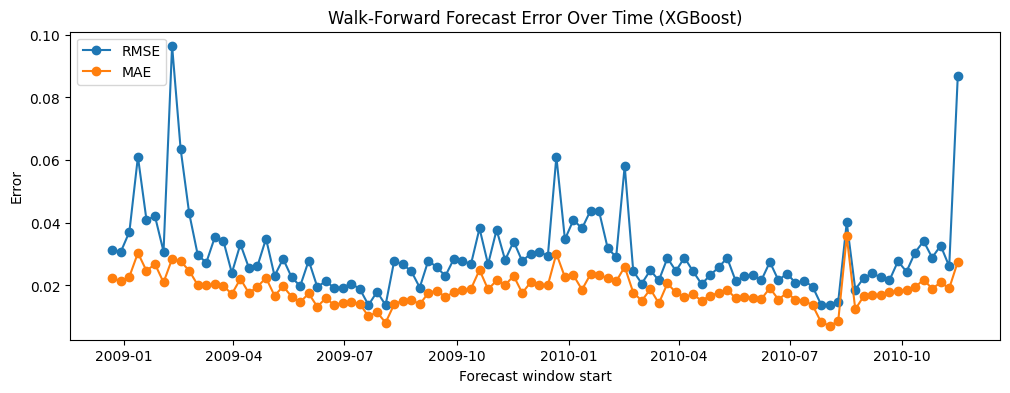

In [ ]:
# Step 3 — Plot walk-forward error over time

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(wf_results_xgb["start_time"], wf_results_xgb["RMSE"], marker="o", label="RMSE")
plt.plot(wf_results_xgb["start_time"], wf_results_xgb["MAE"], marker="o", label="MAE")
plt.title("Walk-Forward Forecast Error Over Time (XGBoost)")
plt.xlabel("Forecast window start")
plt.ylabel("Error")
plt.legend()
plt.show()

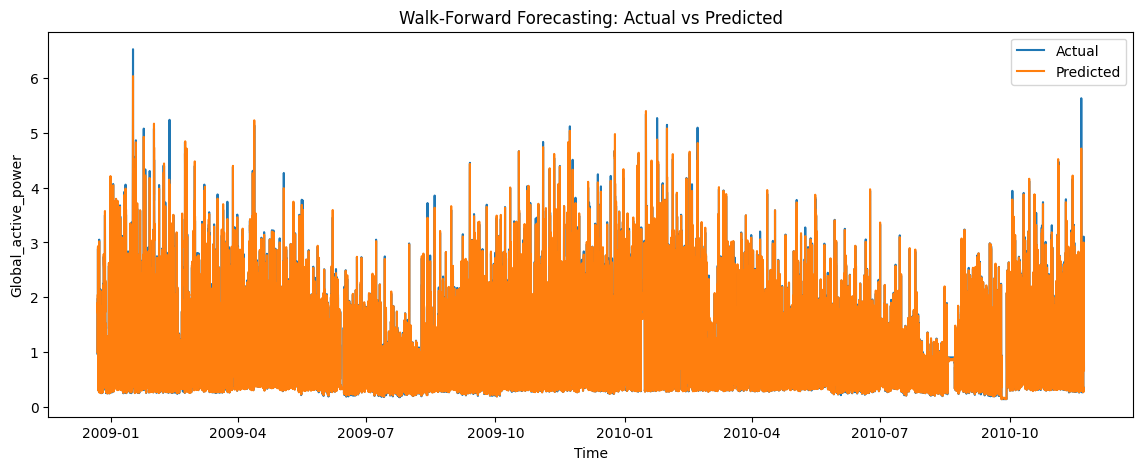

In [ ]:
# Step 4 — Plot actual vs predicted for walk-forward results
plt.figure(figsize=(14,5))
plt.plot(wf_preds_xgb.index, wf_preds_xgb["actual"], label="Actual")
plt.plot(wf_preds_xgb.index, wf_preds_xgb["predicted"], label="Predicted")
plt.title("Walk-Forward Forecasting: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

 **9. Multi-step forecasting (24-hour ahead)**

In [ ]:
# 2) Multi-step forecasting (24-hour ahead)

# Here the model predicts the next 24 hours at once. This is much more realistic for energy demand forecasting.
# it answers 'How far into the future can we predict?' Instead of predicting just the next hour, we predict many future hours at once.

# Input: last 24 hours
# Output: next 24 hours
# Past 24 hours → predict hours 1–24 ahead, So this is a forecasting strategy, not an evaluation strategy

# Single-Step Forecast
# t-24 ... t-1 → predict t  Then next step:t-23 ... t → predict t+1---You predict one time step at a time.
# Multi-Step Forecast
# t-24 ... t-1 → predict [t, t+1, t+2, ... t+23].You predict an entire future horizon.

# Multi-Step Forecasting Is Important. Predicting one step only is often not enough

# | Concept  | Walk-Forward            | Multi-Step               |
# | -------- | ----------------------- | ------------------------ |
# | Purpose  | evaluation              | forecasting strategy     |
# | Predicts | next period repeatedly  | multiple future periods  |
# | Used for | model validation        | real forecasting horizon |
# | Example  | test weekly performance | predict next 24 hours    |

# Multi-Step Is Harder because Errors from each step accumulate and Small mistakes propagate forward. So multi-step forecasting usually has higher error
# Deep Models (LSTM, Transformer) Are Good For Multi-Step. because they can output multiple future steps at once.
# Example: Dense(24) is used for predicting 24 hours ahead.

# Walk-forward → how to evaluate
# Multi-step → how far to predict

# My project built single-step forecasting

# Step 1 — Create 24-step sequences
LOOKBACK = 24
HORIZON = 24
# LOOKBACK = 24
# HORIZON = 24

def create_multistep_sequences(X, y, lookback, horizon):
    Xs, ys = [], []
    X = np.asarray(X)
    y = np.asarray(y)

    for i in range(lookback, len(X) - horizon + 1):
        Xs.append(X[i-lookback:i])
        ys.append(y[i:i+horizon])

    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

In [ ]:
# Step 2 — Build sequence datasets
from sklearn.preprocessing import StandardScaler

seq_train = train[seq_features]
seq_val   = val[seq_features]
seq_test  = test[seq_features]

y_train_ms = train["Global_active_power"]
y_val_ms   = val["Global_active_power"]
y_test_ms  = test["Global_active_power"]

scaler_ms = StandardScaler()
X_train_ms_scaled = scaler_ms.fit_transform(seq_train)
X_val_ms_scaled   = scaler_ms.transform(seq_val)
X_test_ms_scaled  = scaler_ms.transform(seq_test)

X_train_ms, y_train_ms_seq = create_multistep_sequences(X_train_ms_scaled, y_train_ms.values, LOOKBACK, HORIZON)
X_val_ms, y_val_ms_seq     = create_multistep_sequences(X_val_ms_scaled, y_val_ms.values, LOOKBACK, HORIZON)
X_test_ms, y_test_ms_seq   = create_multistep_sequences(X_test_ms_scaled, y_test_ms.values, LOOKBACK, HORIZON)

print(X_train_ms.shape, y_train_ms_seq.shape)

(26456, 24, 14) (26456, 24)


In [ ]:
# Step 3 — LSTM for 24-hour forecasting
import tensorflow as tf

tf.keras.backend.clear_session()

multi_lstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_train_ms.shape[2])),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(HORIZON)
])

multi_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)

history_multi_lstm = multi_lstm.fit(
    X_train_ms,
    y_train_ms_seq,
    validation_data=(X_val_ms, y_val_ms_seq),
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 1.0259 - rmse: 1.0023 - val_loss: 0.4412 - val_rmse: 0.6642
Epoch 2/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.5447 - rmse: 0.7380 - val_loss: 0.4330 - val_rmse: 0.6580
Epoch 3/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.5070 - rmse: 0.7120 - val_loss: 0.4278 - val_rmse: 0.6540
Epoch 4/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.4806 - rmse: 0.6933 - val_loss: 0.4401 - val_rmse: 0.6634
Epoch 5/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.4638 - rmse: 0.6810 - val_loss: 0.4475 - val_rmse: 0.6690
Epoch 6/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.4458 - rmse: 0.6677 - val_loss: 0.4455 - val_rmse: 0.6674
Epoch 7/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.4314 - rmse: 0.6568 - val_loss: 0.4645 - val_rmse: 0.6815
Epoch 8/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.4229 - rmse: 0.6503 - val_loss: 0.4773 - val_rmse: 0.6909
Epoch 9/30
414/414 ━━━━━━━━━━━━━

In [ ]:
# Step 4 — Evaluate multi-step forecast
y_pred_multi_lstm = multi_lstm.predict(X_test_ms, verbose=0)

mae_multi = mean_absolute_error(y_test_ms_seq.flatten(), y_pred_multi_lstm.flatten())
rmse_multi = np.sqrt(mean_squared_error(y_test_ms_seq.flatten(), y_pred_multi_lstm.flatten()))

print("24-step LSTM MAE :", mae_multi)
print("24-step LSTM RMSE:", rmse_multi)

# MAE and RMSE of LSTM were  0.315	and   0.455
# For 24-step LSTM, they are 0.451 and    0.655

# LSTM/Transformer: understand time sequences directly.Deep sequence models process ordered sequences.
# XGBoost: It only sees features.There is no inherent time order.

# Multi-step forecasting means predicting a whole future sequence.
# Transformers use attention mechanisms. Attention allows the model to focus on:which past hours influence each future hour
# Multi-step forecasting is better suited to sequence models because they:learn temporal dependencies, predict entire sequences, avoid recursive error accumulation

# But for tabular structured time-series, tree models like XGBoost can still outperform them

# Model	           Time understanding
# XGBoost	          feature-based
# LSTM	             sequence memory
# Transformer	        attention over sequence

24-step LSTM MAE : 0.45135658979415894
24-step LSTM RMSE: 0.6555976804526994


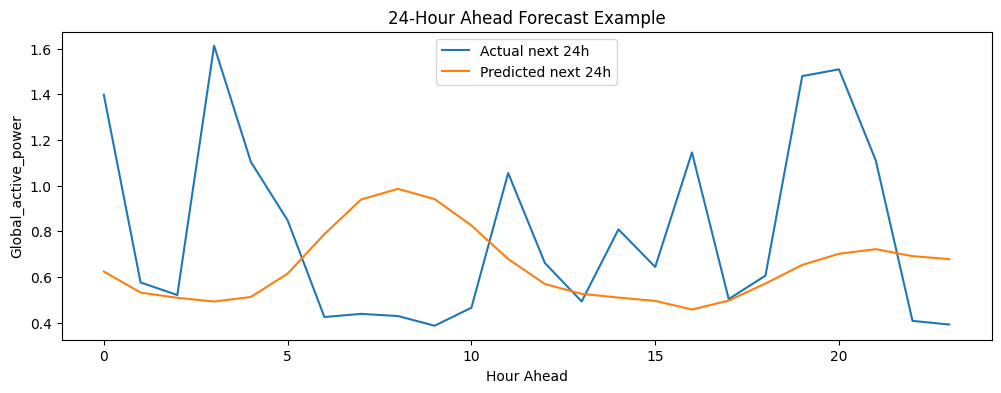

In [ ]:
# Step 5 — Plot one 24-hour forecast horizon
sample_idx = 0

plt.figure(figsize=(12,4))
plt.plot(y_test_ms_seq[sample_idx], label="Actual next 24h")
plt.plot(y_pred_multi_lstm[sample_idx], label="Predicted next 24h")
plt.title("24-Hour Ahead Forecast Example")
plt.xlabel("Hour Ahead")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

**10. Explainability: Transformer Attention**

In [ ]:
# 3) Transformer + attention visualization
#to visualize attention, we need to expose the attention scores.

# Step 1 — Build Transformer with attention output
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)
        self.last_attention_scores = None

    def call(self, inputs, training=False):
        attn_output, attn_scores = self.att(
            inputs, inputs,
            return_attention_scores=True
        )
        self.last_attention_scores = attn_scores
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [ ]:
# Step 2 — Build attention-aware Transformer

def build_transformer_with_attention(input_shape, embed_dim=64, num_heads=4, ff_dim=128):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Dense(embed_dim)(inputs)

    transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
    x = transformer_block(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )

    return model, transformer_block

In [ ]:
# Step 3 — Train it
tf.keras.backend.clear_session()

transformer_attn, transformer_block = build_transformer_with_attention(
    input_shape=(LOOKBACK, X_train_seq.shape[2])
)

history_attn = transformer_attn.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.8140 - rmse: 0.9005 - val_loss: 0.6766 - val_rmse: 0.8225
Epoch 2/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.6890 - rmse: 0.8299 - val_loss: 0.5558 - val_rmse: 0.7455
Epoch 3/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.6187 - rmse: 0.7863 - val_loss: 0.4793 - val_rmse: 0.6923
Epoch 4/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.5183 - rmse: 0.7199 - val_loss: 0.4331 - val_rmse: 0.6581
Epoch 5/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.4681 - rmse: 0.6841 - val_loss: 0.4175 - val_rmse: 0.6461
Epoch 6/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.4420 - rmse: 0.6648 - val_loss: 0.3983 - val_rmse: 0.6311
Epoch 7/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.4165 - rmse: 0.6453 - val_loss: 0.3799 - val_rmse: 0.6164
Epoch 8/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.3904 - rmse: 0.6248 - val_loss: 0.3692 - val_rmse: 0.6076
Epoch 9/20
414/414 ━━━━━━━━━━━━

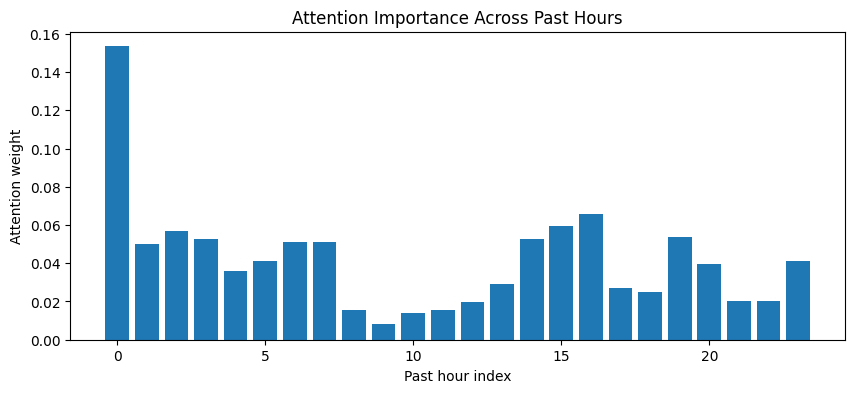

In [ ]:
# Step 4 — Visualize which past hours mattered
# This plot answers:Which past hours in the 24-hour window influenced the forecast most?
sample = X_test_seq[:1]
_ = transformer_attn(sample, training=False)

attention_scores = transformer_block.last_attention_scores.numpy()
# shape: (batch, heads, query_len, key_len)

avg_attention = attention_scores.mean(axis=1)[0]   # average over heads
importance = avg_attention.mean(axis=0)            # average over query positions

plt.figure(figsize=(10,4))
plt.bar(range(len(importance)), importance)
plt.title("Attention Importance Across Past Hours")
plt.xlabel("Past hour index")
plt.ylabel("Attention weight")
plt.show()

# Traditional sequence models (like LSTM) process time step-by-step
# Information must pass through many steps, so long-range dependencies can be forgotten. it’s hard to know which past point mattered most
# Transformers solve this using attention.
# Attention allows the model to ask:“Which past time points are most important for predicting the future?”
# Instead of treating all past inputs equally, the model assigns weights.
# For every prediction, the model computes importance scores: attention weight = importance of a past timestep

# Observations:
# Highest attention at hour index 0: The first bar (~0.15) is the largest.
# This likely corresponds to most recent observation. Meaning the model strongly relies on recent electricity usage.
# Moderate attention around hours 14–16. past hour index ≈ 14–16. That suggests the model also considers earlier parts of the day when predicting

# What the Attention Plot Is Telling? Model likely learned: daily periodicity, Specifically: same hour yesterday strongly predicts next-hour demand

# This is exactly what we expect in electricity forecasting

# The attention mechanism indicates that the model assigns the highest importance to the observation from 24 hours earlier,
# reflecting the strong daily periodicity in electricity consumption patterns.

# high weight at 0 means strong daily cycle


**11. Anomaly Detection**

In [ ]:
# 4) Anomaly detection using forecast errors

# This is extremely useful in real systems. forecast expected usage, compare with actual, large residuals = anomalies

# Step 1 — Compute residuals from XGBoost walk-forward predictions
wf_preds_xgb["residual"] = wf_preds_xgb["actual"] - wf_preds_xgb["predicted"]

# Step 2 — Create anomaly threshold

# Simple rule: flag residuals above 3 standard deviations.
resid_mean = wf_preds_xgb["residual"].mean()
resid_std = wf_preds_xgb["residual"].std()

upper = resid_mean + 3 * resid_std
lower = resid_mean - 3 * resid_std

wf_preds_xgb["anomaly"] = (
    (wf_preds_xgb["residual"] > upper) |
    (wf_preds_xgb["residual"] < lower)
).astype(int)

print("Number of anomalies:", wf_preds_xgb["anomaly"].sum())

# An anomaly is a data point that behaves very differently from what the model expects.
# anomaly = actual electricity usage is much higher or lower than predicted
# Residual (Forecast Error): Residual = Actual value − Predicted value
# uses a threshold on the residual.
# threshold = mean(residual) ± 3 × std(residual)
# Anomalies occur when | residual | > threshold that means prediction error is unusually large

# Upper threshold  → unusually high error
# Lower threshold  → unusually low error

# Large spikes in electricity usage: power suddenly jumps above normal pattern
# Sudden drops: power suddenly drops
# Clusture of anomalies: Periods with unusual consumption patterns. behavior changed temporarily

# forecasting model learned normal electricity usage patterns. When actual data deviates from those patterns the residual becomes large
# and This flags an anomaly
# anomalies mean:unexpected usage relative to learned patterns

Number of anomalies: 167


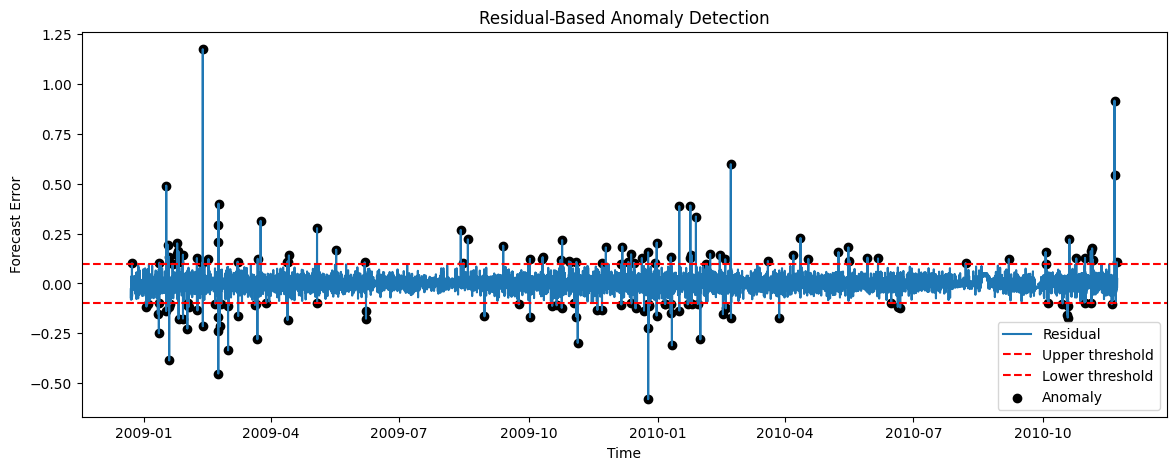

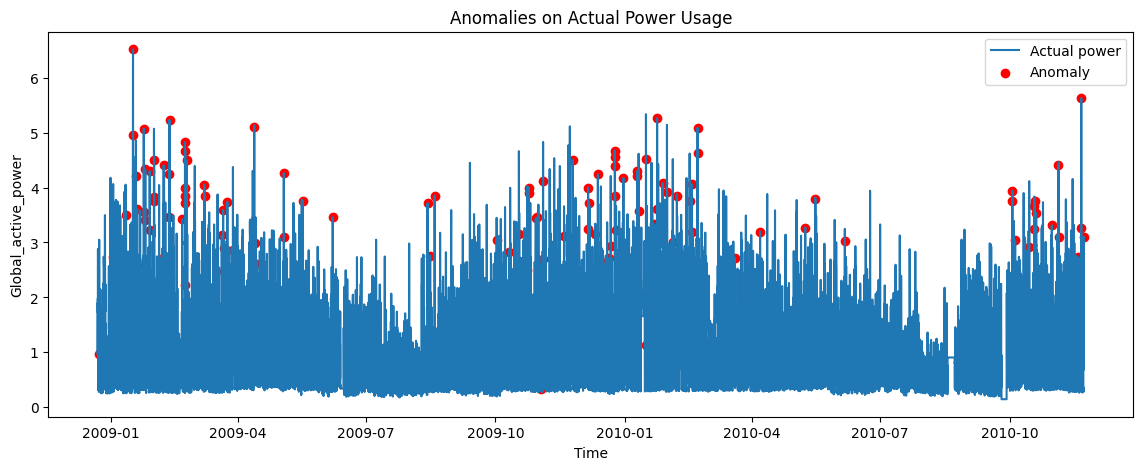

In [ ]:
# Step 3 — Plot anomalies on residuals
plt.figure(figsize=(14,5))
plt.plot(wf_preds_xgb.index, wf_preds_xgb["residual"], label="Residual")
plt.axhline(upper, color="red", linestyle="--", label="Upper threshold")
plt.axhline(lower, color="red", linestyle="--", label="Lower threshold")

anoms = wf_preds_xgb[wf_preds_xgb["anomaly"] == 1]
plt.scatter(anoms.index, anoms["residual"], color="black", label="Anomaly")

plt.title("Residual-Based Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Forecast Error")
plt.legend()
plt.show()

# Step 4 — Plot anomalies on actual power usage
plt.figure(figsize=(14,5))
plt.plot(wf_preds_xgb.index, wf_preds_xgb["actual"], label="Actual power")
plt.scatter(anoms.index, wf_preds_xgb.loc[anoms.index, "actual"], color="red", label="Anomaly")
plt.title("Anomalies on Actual Power Usage")
plt.xlabel("Time")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

# conclusion
# Residual-based anomaly detection was performed using the forecasting model.
# Anomalies were identified when the prediction error exceeded predefined thresholds.
# The detected anomalies correspond to unusual spikes or drops in electricity consumption, indicating potential abnormal appliance usage
# or unexpected household activity.


**12. Trend Analysis**

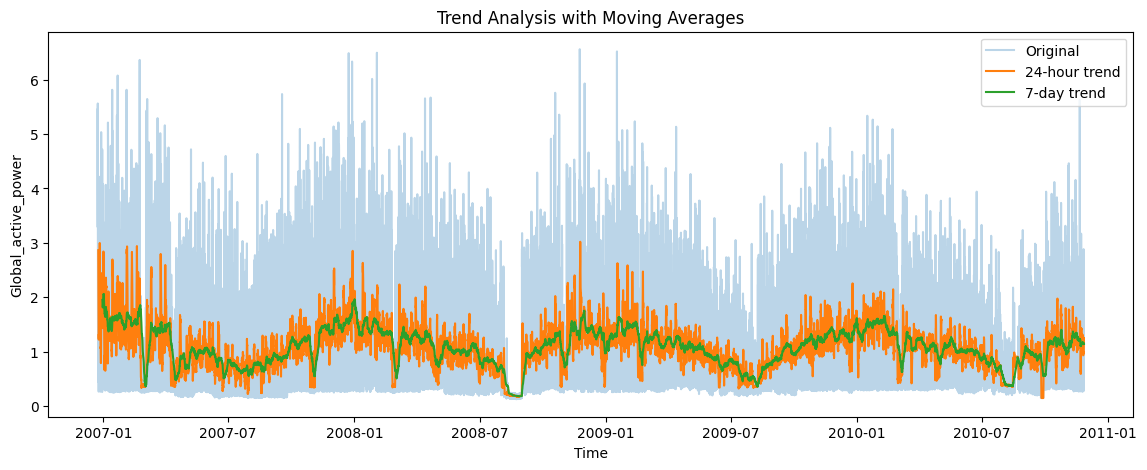

In [ ]:
# 5) Trend analysis

# Trend analysis helps you understand the longer-term movement and seasonal structure.
# Step 1 — Moving average trend
df_hourly["trend_24h"] = df_hourly["Global_active_power"].rolling(24).mean()
df_hourly["trend_7d"] = df_hourly["Global_active_power"].rolling(24*7).mean()

plt.figure(figsize=(14,5))
plt.plot(df_hourly.index, df_hourly["Global_active_power"], alpha=0.3, label="Original")
plt.plot(df_hourly.index, df_hourly["trend_24h"], label="24-hour trend")
plt.plot(df_hourly.index, df_hourly["trend_7d"], label="7-day trend")
plt.title("Trend Analysis with Moving Averages")
plt.xlabel("Time")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

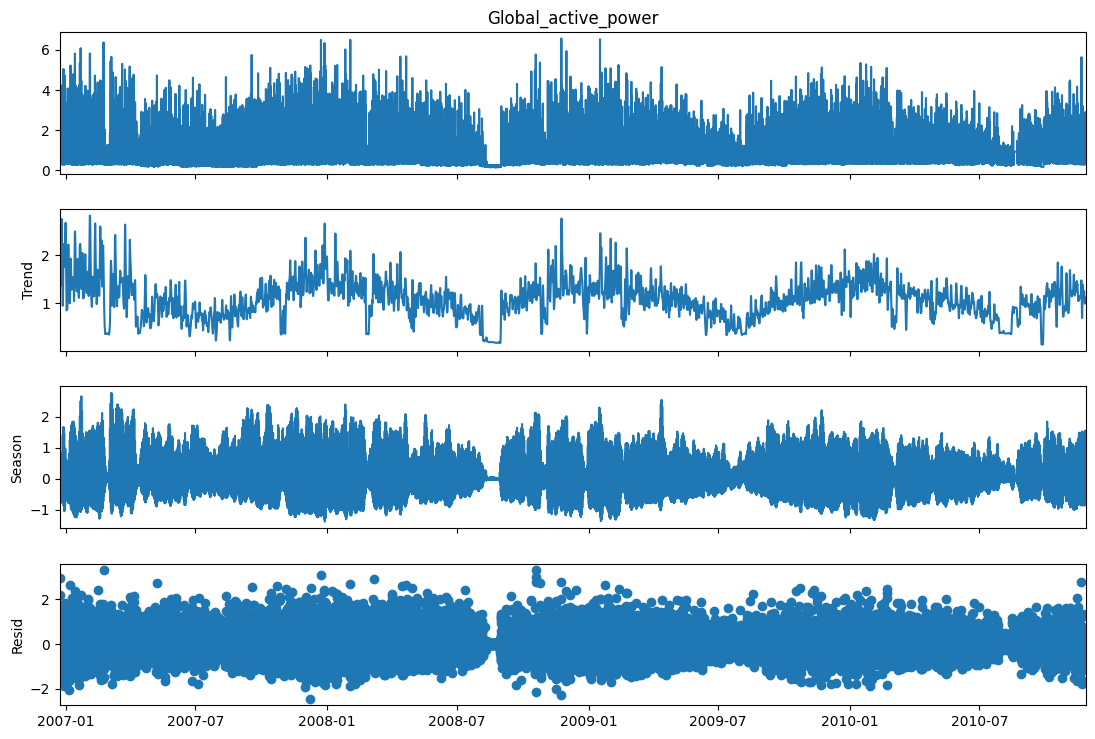

In [ ]:
# Step 2 — Seasonal decomposition
from statsmodels.tsa.seasonal import STL

stl = STL(df_hourly["Global_active_power"], period=24)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

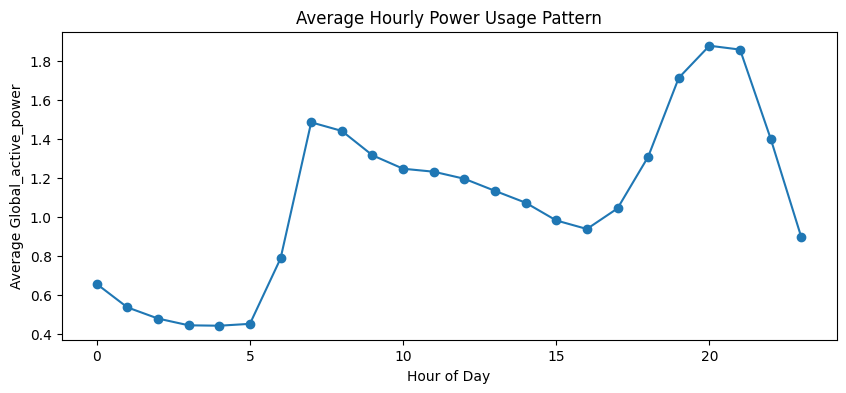

In [ ]:
# Step 3 — Average hourly pattern
hourly_profile = df_hourly.groupby(df_hourly.index.hour)["Global_active_power"].mean()

plt.figure(figsize=(10,4))
plt.plot(hourly_profile.index, hourly_profile.values, marker="o")
plt.title("Average Hourly Power Usage Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Global_active_power")
plt.show()

# Trend analysis helps us separate long-term behavior from short-term fluctuations in time-series data.
# The three figures show exactly how electricity consumption can be decomposed into trend, seasonality, and noise.

# Trend: Long-term movement in the data.
# Seasonality: Regular repeating patterns.
# Noise / Residual: Random fluctuations or unexplained variation.


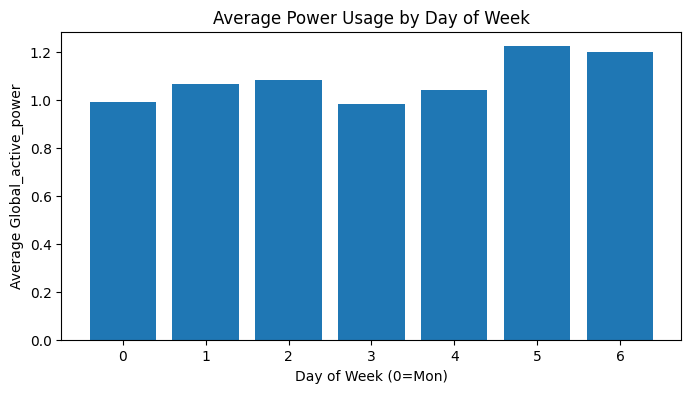

In [ ]:
# Step 4 — Average weekday pattern
weekday_profile = df_hourly.groupby(df_hourly.index.dayofweek)["Global_active_power"].mean()

plt.figure(figsize=(8,4))
plt.bar(weekday_profile.index, weekday_profile.values)
plt.title("Average Power Usage by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Global_active_power")
plt.show()

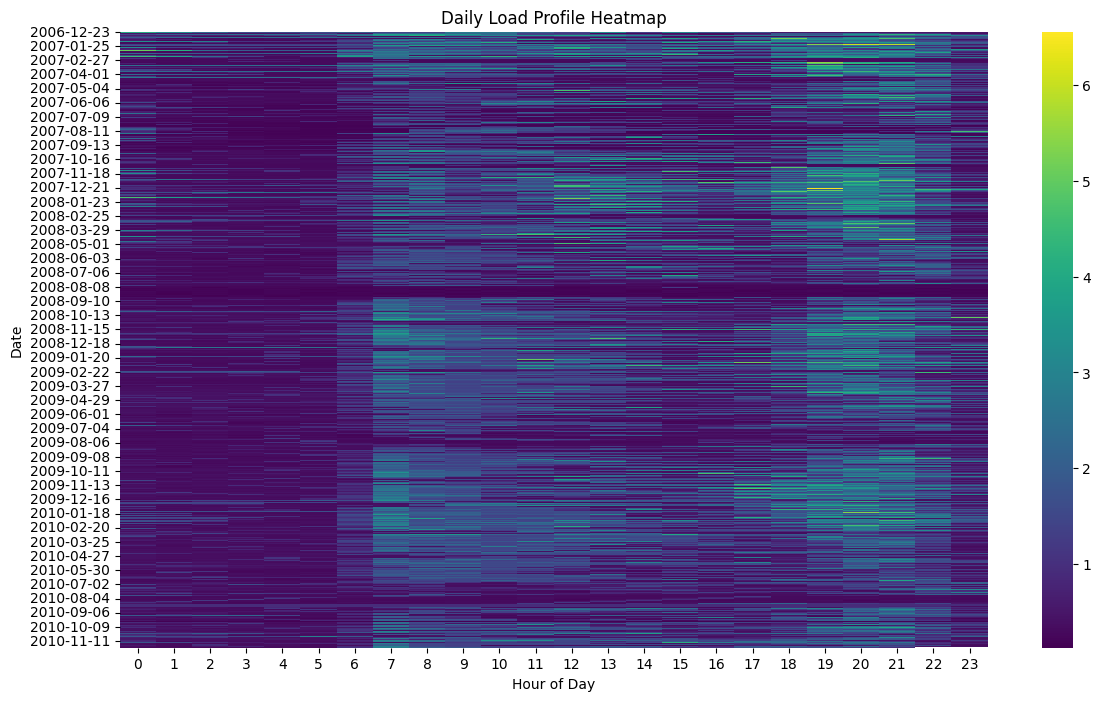

In [ ]:
# Step 5 — Heatmap trend visualization
import seaborn as sns

df_heat = df_hourly.copy()
df_heat["date"] = df_heat.index.date
df_heat["hour"] = df_heat.index.hour

heatmap_data = df_heat.pivot_table(
    values="Global_active_power",
    index="date",
    columns="hour"
)

plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Daily Load Profile Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Date")
plt.show()